<a href="https://colab.research.google.com/github/MinThuKhant763/machine-learning/blob/main/Decision_Tree_for_Binary_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from sklearn import datasets
bc = datasets.load_breast_cancer()
#print(bc.DESCR)
#print(bc.feature_names)
#print(bc.target_names)
X = bc.data
print(X.shape)
y = bc.target
print(y.shape)
print(set(y))

(569, 30)
(569,)
{np.int64(0), np.int64(1)}


In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
#print(X_train)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model_tree = DecisionTreeClassifier(max_depth=5,random_state=42)
model_tree.fit(X_train,y_train)
y_pred = model_tree.predict(X_test)
acc_tree = accuracy_score(y_test,y_pred)
print(f"Accuracy of Decision Tree model : {acc_tree:.4f}")

Accuracy of Decision Tree model : 0.9474


In [22]:
from sklearn.metrics import classification_report
target_names = bc.target_names
print(classification_report(y_test,y_pred,target_names=target_names))

              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [23]:
from sklearn.tree import export_graphviz
export_graphviz(model_tree,out_file="tree.dot",class_names=['malignant','benign'],feature_names=bc.feature_names,impurity=True,filled=True)


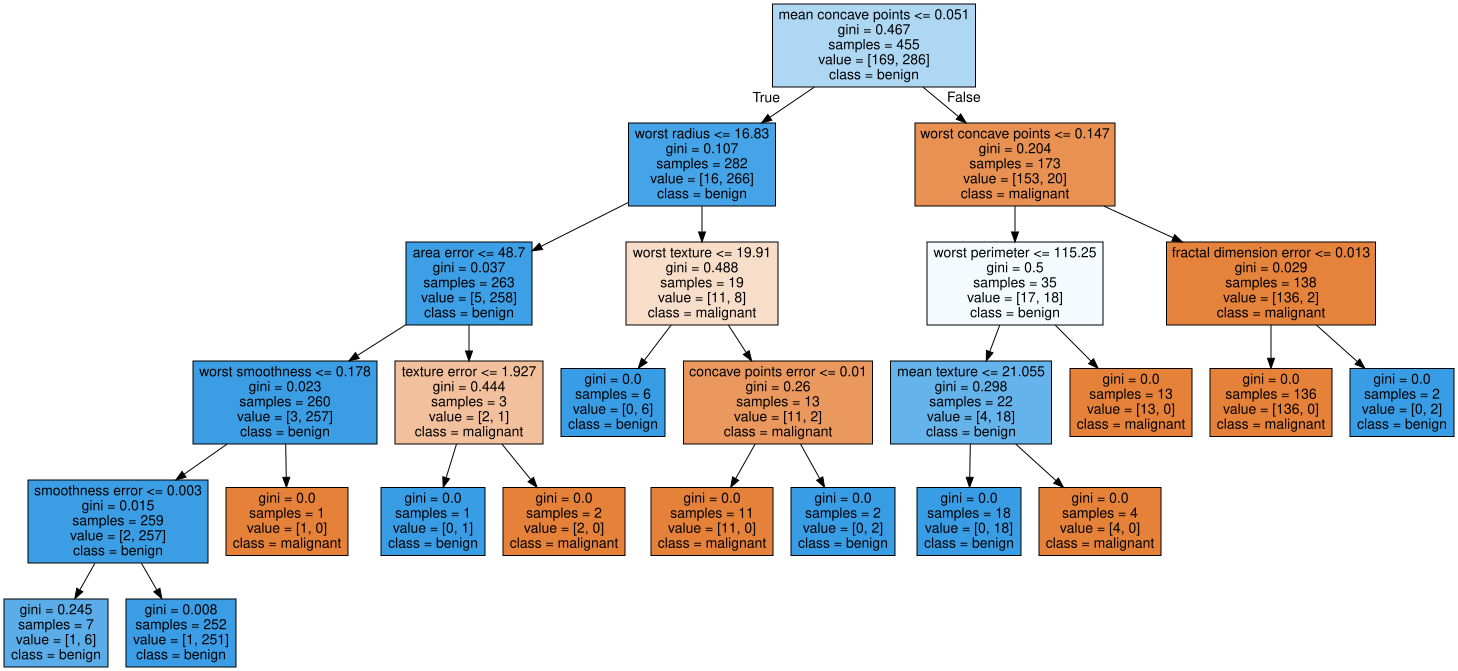

In [27]:
import graphviz
with open('tree.dot')as f:
  dot_graph = f.read()
graphviz.Source(dot_graph)